### **Shahid Patel | 31 | 232A004**

***ExperimentcNo.4: Applying dynamic programming algorithms, such as policy evaluation and policy***

In [55]:
print("Shahid Patel | 31 | 232A004")
!pip install gym

Shahid Patel | 31 | 232A004


In [56]:
print("Shahid Patel | 31 | 232A004")
!pip install gridworld

Shahid Patel | 31 | 232A004


Shahid Patel | 31 | 232A004


array([[[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]],

       [[180, 200, 230],
        [204, 230, 255],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [204, 230, 255],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       ...,

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [235, 245, 249],
        [180, 200, 230]],

       [[180, 200, 230],
        [235, 245, 249],
        [235, 245, 249],
        ...,
        [204, 230, 255],
        [204, 230, 255],
        [180, 200, 230]],

       [[180, 200, 230],
        [180, 200, 230],
        [180, 200, 230],
        ...,
        [180, 200, 230],
        [180, 200, 230],
        [180, 200, 230]]], dtype=uint8)
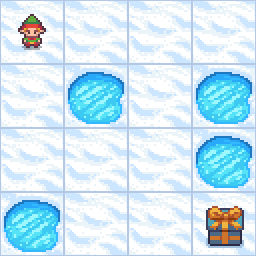

In [57]:
print("Shahid Patel | 31 | 232A004")
import gymnasium as gym
import numpy as np

env = gym.make('FrozenLake-v1', render_mode='rgb_array')
env.reset()
env.render()

In [58]:
print("Shahid Patel | 31 | 232A004")
env.observation_space.n

Shahid Patel | 31 | 232A004


np.int64(16)

In [59]:
print("Shahid Patel | 31 | 232A004")
np.zeros(4)

Shahid Patel | 31 | 232A004


array([0., 0., 0., 0.])

In [60]:
print("Shahid Patel | 31 | 232A004")
def policy_evaluation(policy, environment, discount_factor=1.0, theta=1e-9, max_iterations=1e9):

    # Initialize the value function for each state to zero
    V = np.zeros(environment.observation_space.n)

    # Number of evaluation iterations
    evaluation_iterations = 1

    for i in range(int(max_iterations)):
        delta = 0
        evaluation_iterations += 1

        # Iterate through each state
        for state in range(environment.observation_space.n):
            v = 0

            for action, action_prob in enumerate(policy[state]):

                # For each action, look at possible next states
                for prob, next_state, reward, done in environment.P[state][action]:
                    v += action_prob * prob * (
                        reward + discount_factor * V[next_state]
                    )

            # Calculate change in value
            delta = max(delta, abs(V[state] - v))

            # Update value function
            V[state] = v

        # Check for convergence
        if delta < theta:
          print(f"Policy evaluated in {evaluation_iterations} iterations.")
          return V
    print(f"Maximum iterations reached. Policy evaluated in {evaluation_iterations} iterations.")
    return V

Shahid Patel | 31 | 232A004


In [61]:
print("Shahid Patel | 31 | 232A004")
def one_step_lookahead(environment, state, V, discount_factor):
      action_values = np.zeros(environment.action_space.n)
      for action in range(environment.action_space.n):
        for probability, next_state, reward, terminated in environment. P[state][action]:
          action_values[action] += probability * (reward + discount_factor * V[next_state])
      return action_values

Shahid Patel | 31 | 232A004


In [62]:
print("Shahid Patel | 31 | 232A004")
def policy_iteration(environment, discount_factor=1.0, max_iterations=1e9):
  # Start with a random policy
  policy = np.ones([environment.observation_space.n, environment.action_space.n]) / environment.action_space.n
  # Initialize counter of evaluated policies
  evaluated_policies = 0
  # Repeat until convergence or critical number of iterations reached
  for i in range(int(max_iterations)):
    # Evaluate current policy
    V = policy_evaluation(policy, environment, discount_factor=discount_factor)

    stable_policy = True # Assume policy is stable at the beginning of each iteration

    # Go through each state and try to improve actions that were taken (policy Improvement)
    for state in range(environment.observation_space.n):
      current_action = np.argmax(policy[state]) # Store the action from the current policy
      # Find the best action by looking one step ahead
      action_values = one_step_lookahead(environment, state, V, discount_factor)
      # Select a better action
      best_action = np.argmax(action_values)

      # If the action changed, the policy is not stable
      if current_action != best_action:
        stable_policy = False
        # Greedy policy update
        policy[state] = np.eye(environment.action_space.n)[best_action]

    evaluated_policies += 1

    # If the policy is stable, we have found the optimal policy
    if stable_policy:
      print(f"Evaluated {evaluated_policies} policies")
      return policy, V

  print(f"Maximum iterations reached. Policy not fully converged after {max_iterations} iterations.")
  return policy, V

Shahid Patel | 31 | 232A004


In [63]:
print("Shahid Patel | 31 | 232A004")
optimal_policy_vi, optimal_value_function_vi = value_iteration(env.unwrapped)

print("Optimal Policy (Value Iteration):")
print(optimal_policy_vi)
print("\nOptimal Value Function (Value Iteration):")
print(optimal_value_function_vi)

Shahid Patel | 31 | 232A004
Value-iteration converged at iteration #523.
Optimal Policy (Value Iteration):
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]

Optimal Value Function (Value Iteration):
[0.82352939 0.82352939 0.82352939 0.82352938 0.8235294  0.
 0.52941175 0.         0.8235294  0.8235294  0.76470587 0.
 0.         0.88235293 0.94117647 0.        ]


In [64]:
print("Shahid Patel | 31 | 232A004")
optimal_policy, optimal_value_function = policy_iteration(env.unwrapped)

print("Optimal Policy:")
print(optimal_policy)
print("\nOptimal Value Function:")
print(optimal_value_function)

Shahid Patel | 31 | 232A004
Policy evaluated in 66 iterations.
Policy evaluated in 170 iterations.
Policy evaluated in 428 iterations.
Evaluated 3 policies
Optimal Policy:
[[0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   1.   0.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]]

Optimal Value Function:
[0.13218389 0.13218389 0.13218388 0.13218388 0.1321839  0.
 0.11494252 0.         0.26436781 0.39655172 0.3275862  0.
 0.         0.59770115 0.79885057 0.        ]


In [65]:
print("Shahid Patel | 31 | 232A004")
optimal_policy, optimal_value_function = policy_iteration(env.unwrapped)

print("Optimal Policy:")
print(optimal_policy)
print("\nOptimal Value Function:")
print(optimal_value_function)

Shahid Patel | 31 | 232A004
Policy evaluated in 66 iterations.
Policy evaluated in 170 iterations.
Policy evaluated in 428 iterations.
Evaluated 3 policies
Optimal Policy:
[[0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.   0.   0.   1.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   0.   1.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.   0.   1.   0.  ]
 [0.   1.   0.   0.  ]
 [0.25 0.25 0.25 0.25]]

Optimal Value Function:
[0.13218389 0.13218389 0.13218388 0.13218388 0.1321839  0.
 0.11494252 0.         0.26436781 0.39655172 0.3275862  0.
 0.         0.59770115 0.79885057 0.        ]


In [66]:
np.eye(env.action_space.n)[0]

array([1., 0., 0., 0.])

In [67]:
print("Shahid Patel | 31 | 232A004")
def value_iteration(environment, discount_factor=1.0, theta=1e-9, max_iterations=1e9):
    # Initialize state-value function with zeros for each environment state
    V = np.zeros(environment.observation_space.n)

    for i in range(int(max_iterations)):
        # Early stopping condition
        delta = 0

        # Update each state
        for state in range(environment.observation_space.n):
            # Do a one-step lookahead to calculate state-action values
            action_value = one_step_lookahead(environment, state, V, discount_factor)

            # Select best action to perform based on the highest state-action value
            best_action_value = np.max(action_value)

            # Calculate change in value
            delta = max(delta, np.abs(V[state] - best_action_value))

            # Update the value function for current state
            V[state] = best_action_value

        # Check if we can stop
        if delta < theta:
            print(f'Value-iteration converged at iteration #{i}.')
            break
    # Create a deterministic policy using the optimal value function
    policy = np.zeros([environment.observation_space.n, environment.action_space.n])

    for state in range(environment.observation_space.n):
        # One step lookahead to find the best action for this state
        action_value = one_step_lookahead(environment, state, V, discount_factor)

        # Select best action based on the highest state-action value
        best_action = np.argmax(action_value)

        # Update the policy to perform a better action at a current state
        policy[state, best_action] = 1.0

    return policy, V

Shahid Patel | 31 | 232A004


In [68]:
print("Shahid Patel | 31 | 232A004")
def play_episodes(environment, n_episodes, policy):
    wins = 0
    total_reward = 0
    for episode in range(n_episodes):
        terminated = False
        # The env.reset() method returns a tuple: observation, info
        # For Gymnasium environments, it's (observation, info)
        state, info = environment.reset()
        while not terminated:
            # Select best action to perform in a current state
            action = np.argmax(policy[state])
            # Perform an action and observe how environment acted in response
            # For Gymnasium environments, step returns (observation, reward, terminated, truncated, info)
            next_state, reward, terminated, truncated, info = environment.step(action)
            # Summarize total reward
            total_reward += reward
            # Update current state
            state = next_state
        # Calculate number of wins over episodes after the episode terminates
        if terminated and reward == 1.0: # Assuming reward 1.0 means a win
            wins += 1
    average_reward = total_reward / n_episodes # Calculate average reward after all episodes
    return wins, total_reward, average_reward

# Number of episodes to play
n_episodes = 10000

# Functions to find best policy
solvers = [('Policy Iteration', policy_iteration), ('Value Iteration', value_iteration)]

for iteration_name, iteration_func in solvers:
    # Load a Frozen Lake environment
    # Re-create environment for each solver if needed, or pass the existing one
    # For accurate comparison, it's good to start with a fresh environment for each solver
    environment = gym.make('FrozenLake-v1')
    # Search for an optimal policy using the iteration function
    # Use environment.unwrapped to access the underlying environment with the 'P' attribute
    policy, V = iteration_func(environment.unwrapped)

    # Apply best policy to the real environment
    wins, total_reward, average_reward = play_episodes(environment, n_episodes, policy)

    print(f'{iteration_name}:: number of wins over {n_episodes} episodes = {wins}')
    print(f'{iteration_name} average reward over {n_episodes} episodes = {average_reward}\n\n')

Shahid Patel | 31 | 232A004
Policy evaluated in 66 iterations.
Policy evaluated in 170 iterations.
Policy evaluated in 428 iterations.
Evaluated 3 policies
Policy Iteration:: number of wins over 10000 episodes = 8226
Policy Iteration average reward over 10000 episodes = 0.8226


Value-iteration converged at iteration #523.
Value Iteration:: number of wins over 10000 episodes = 8268
Value Iteration average reward over 10000 episodes = 0.8268


